In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import networkx as nx
from scipy.stats import entropy, chi2
from scipy.linalg import eig
import plotly.graph_objects as go
import numpy as np
from itertools import permutations

pd.set_option('display.float_format', '{:.3f}'.format)
sns.set_style('white')
plt.rcParams['figure.dpi'] = 100

In [3]:
df = pd.read_csv('data/final_corpus.csv', sep=';')
df['year'] = pd.to_datetime(df['date'], errors='coerce').dt.year

TOP_PAIRS = {
    frozenset(['accusation', 'presentation']): 'accusation+presentation',
    frozenset(['presentation', 'appeal']): 'presentation+appeal',
    frozenset(['accusation', 'appeal']): 'accusation+appeal',
}

def collapse_state(row):
    s1, s2 = row['ensemble_strategy1'], row['ensemble_strategy2']
    if pd.isna(s2) or str(s2).strip() == '':
        return s1
    pair = frozenset([s1, s2])
    return TOP_PAIRS.get(pair, s1)

df['state'] = df.apply(collapse_state, axis=1)

STATES = ['presentation', 'accusation', 'appeal', 'self-justification',
          'accusation+presentation', 'presentation+appeal', 'accusation+appeal']
SHORT = {
    'presentation': 'pres',
    'accusation': 'accus',
    'appeal': 'appeal',
    'self-justification': 'self-just',
    'accusation+presentation': 'accus+pres',
    'presentation+appeal': 'pres+app',
    'accusation+appeal': 'accus+app',
}
STATE_IDX = {s: i for i, s in enumerate(STATES)}
DROP = {'-', 'no_strategy'}
K = len(STATES)

print(f'Total rows: {len(df)}')
print(f'Content rows: {(~df["state"].isin(DROP)).sum()}')
print(f'States ({len(STATES)}): {STATES}')

Total rows: 42284
Content rows: 16734
States (7): ['presentation', 'accusation', 'appeal', 'self-justification', 'accusation+presentation', 'presentation+appeal', 'accusation+appeal']


In [4]:
def inventory_row(label, sub):
    content = sub[~sub['state'].isin(DROP)]
    return {
        'slice': label,
        'rows': len(sub),
        'content_rows': len(content),
        'debates': sub['link'].nunique() if 'link' in sub.columns else None,
        'speakers': content['speaker'].nunique() if 'speaker' in content.columns else None,
    }

inventory = [
    inventory_row('all', df),
    inventory_row('general', df[df['election_type'] == 'General Election']),
    inventory_row('primary', df[df['election_type'].isin(
        ['Primary Election: Republican Party', 'Primary Election: Democratic Party'])]),
    inventory_row('primary_republican', df[df['election_type'] == 'Primary Election: Republican Party']),
    inventory_row('primary_democratic', df[df['election_type'] == 'Primary Election: Democratic Party']),
]
inventory_df = pd.DataFrame(inventory)
inventory_df.to_csv('results/corpus_inventory.csv', sep=';', index=False)
inventory_df

,slice,rows,content_rows,debates,speakers
0,all,42284,16734,174,104
1,general,8993,3819,49,34
2,primary,33291,12915,125,86
3,primary_republican,18754,7355,73,49
4,primary_democratic,14537,5560,52,43


In [5]:
def collect_transitions(sub_df):
    '''Return (same_speaker, cross_speaker) lists of (x, y) state pairs.'''
    content = sub_df[~sub_df['state'].isin(DROP)].sort_values(['link', 'order'])
    same, cross = [], []
    for _, grp in content.groupby('link'):
        states = grp['state'].tolist()
        speakers = grp['speaker'].tolist()
        for i in range(len(states) - 1):
            x, y = states[i], states[i + 1]
            if x not in STATE_IDX or y not in STATE_IDX:
                continue
            (same if speakers[i] == speakers[i + 1] else cross).append((x, y))
    return same, cross

def collect_cross(sub_df):
    return collect_transitions(sub_df)[1]

def build_matrix(transitions):
    '''Return (count matrix, transition probability matrix).'''
    C = np.zeros((len(STATES), len(STATES)), dtype=int)
    for x, y in transitions:
        C[STATE_IDX[x], STATE_IDX[y]] += 1
    P = np.zeros((len(STATES), len(STATES)))
    row_sums = C.sum(axis=1)
    for i in range(len(STATES)):
        if row_sums[i] > 0:
            P[i] = C[i] / row_sums[i]
    return C, P

def stationary(P):
    '''Stationary distribution of P (left eigenvector for eigenvalue 1).'''
    eigvals, eigvecs = eig(P.T)
    idx = np.argmin(np.abs(eigvals - 1.0))
    pi = np.real(eigvecs[:, idx])
    return np.abs(pi / pi.sum())

def row_entropies(P):
    return np.array([entropy(P[i] + 1e-12, base=2) for i in range(K)])

In [6]:
BASELINE = 1 / len(STATES)

def plot_diverging_matrix(P, title, ax, vmax=None, fmt='.2f'):
    if vmax is None:
        vmax = max(0.3, np.nanmax(np.abs(P - BASELINE)) + BASELINE)
    norm = mcolors.TwoSlopeNorm(vmin=0, vcenter=BASELINE, vmax=vmax)
    sns.heatmap(
        P, annot=True, fmt=fmt, cmap='RdBu_r', center=BASELINE, norm=norm,
        xticklabels=[SHORT[s] for s in STATES],
        yticklabels=[SHORT[s] for s in STATES],
        cbar_kws={'label': f'P(Y|X), baseline={BASELINE:.2f}'},
        annot_kws={'size': 9}, linewidths=0.5, linecolor='white', ax=ax,
    )
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Next state (Y)')
    ax.set_ylabel('Current state (X)')

def plot_diff_matrix(P_a, P_b, label_a, label_b, ax, vmax=0.2):
    diff = P_a - P_b
    sns.heatmap(
        diff, annot=True, fmt='+.2f', cmap='RdBu_r', center=0, vmin=-vmax, vmax=vmax,
        xticklabels=[SHORT[s] for s in STATES],
        yticklabels=[SHORT[s] for s in STATES],
        cbar_kws={'label': f'P({label_a}) − P({label_b})'},
        annot_kws={'size': 9}, linewidths=0.5, linecolor='white', ax=ax,
    )
    ax.set_title(f'Difference: {label_a} − {label_b}', fontsize=12)
    ax.set_xlabel('Next state (Y)')
    ax.set_ylabel('Current state (X)')

Same-speaker transitions:    5261
Cross-speaker transitions:  11299


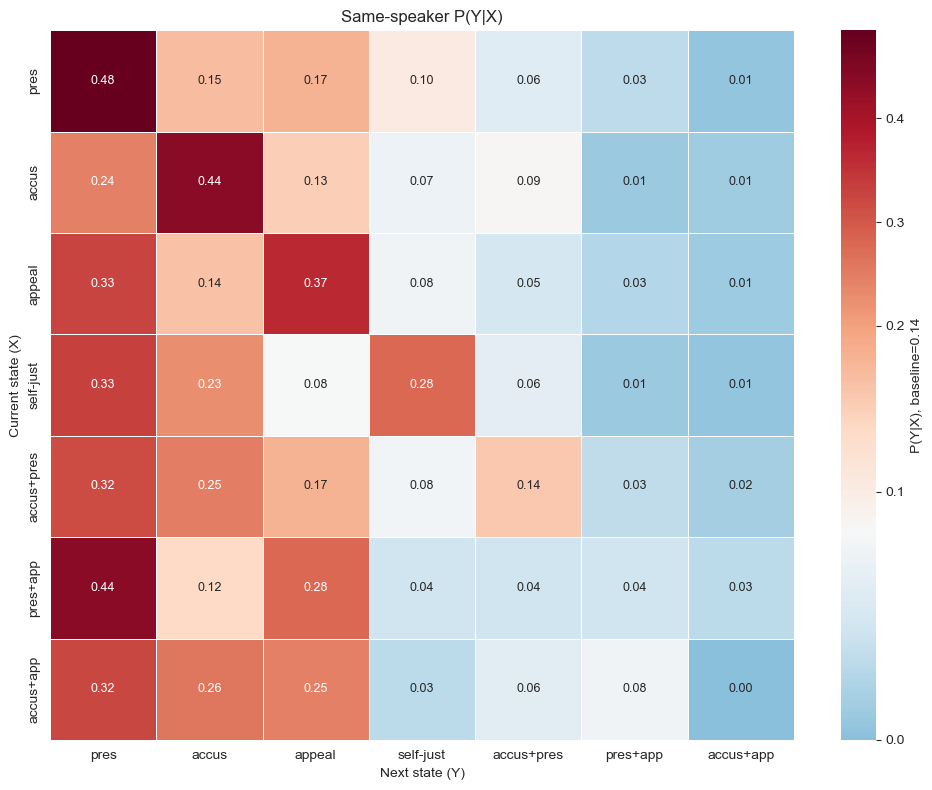

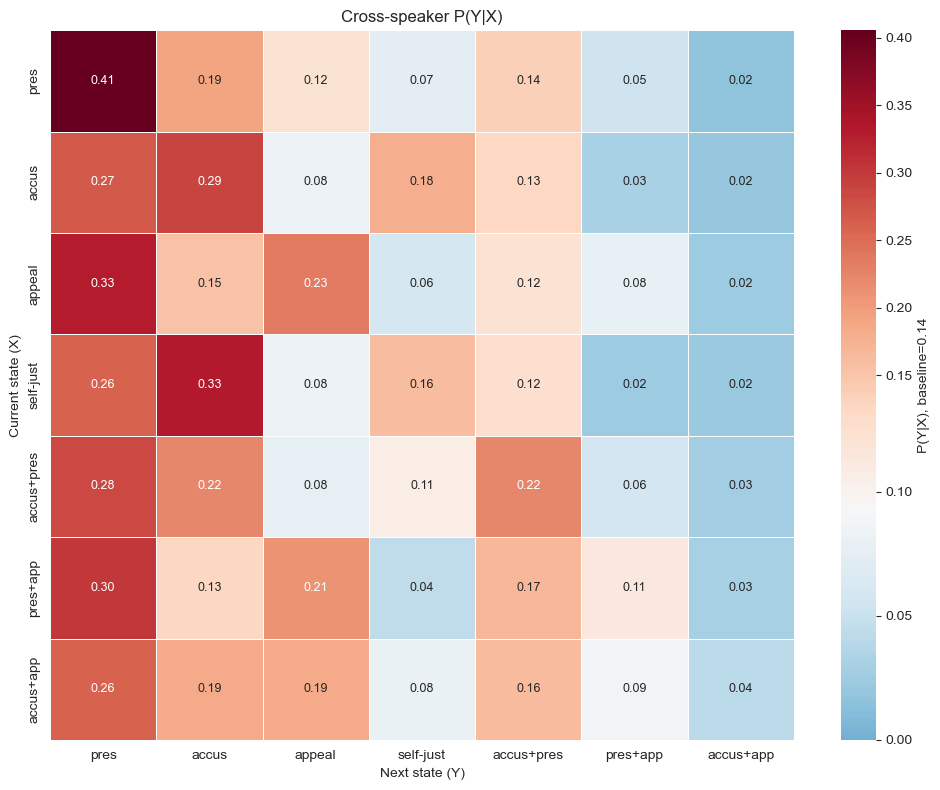

In [7]:
same_all, cross_all = collect_transitions(df)
C_same, P_same   = build_matrix(same_all)
C_cross, P_cross = build_matrix(cross_all)

print(f'Same-speaker transitions:  {len(same_all):>6}')
print(f'Cross-speaker transitions: {len(cross_all):>6}')

fig, ax = plt.subplots(figsize=(10, 8))
plot_diverging_matrix(P_same, 'Same-speaker P(Y|X)', ax)
plt.tight_layout()
plt.savefig('results/fig_01a_same_speaker_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(10, 8))
plot_diverging_matrix(P_cross, 'Cross-speaker P(Y|X)', ax)
plt.tight_layout()
plt.savefig('results/fig_01b_cross_speaker_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
def _best_circular_order(P, top_k=3, min_weight=0.10):
    n = len(STATES)
    edges = []
    for i in range(n):
        cand = [(j, P[i, j]) for j in range(n)
                if i != j and P[i, j] >= min_weight]
        cand.sort(key=lambda t: -t[1])
        for j, w in cand[:top_k]:
            edges.append((i, j, w))

    def cost(order):
        pos = {node: k for k, node in enumerate(order)}
        c = 0
        for i, j, w in edges:
            d = abs(pos[i] - pos[j])
            d = min(d, n - d)
            c += w * d
        return c

    best = min(permutations(range(n)), key=cost)
    return [STATES[k] for k in best]


def plot_graph_topk_plotly(P, top_k=3, min_weight=0.10, radius=1.0):
    order = _best_circular_order(P, top_k=top_k, min_weight=min_weight)
    n = len(order)
    angles = [2 * np.pi * k / n - np.pi / 2 for k in range(n)]
    pos = {s: (radius * np.cos(a), radius * np.sin(a))
           for s, a in zip(order, angles)}

    edges = []
    for i, x in enumerate(STATES):
        cand = [(STATES[j], P[i, j]) for j in range(len(STATES))
                if i != j and P[i, j] >= min_weight]
        cand.sort(key=lambda t: -t[1])
        edges.extend([(x, y, w) for y, w in cand[:top_k]])

    edge_set = {(u, v) for u, v, _ in edges}

    fig = go.Figure()

    obstacles = [(x, y, 0.13) for x, y in pos.values()]
    placed_labels = []
    LABEL_R = 0.06

    def is_free(cx, cy):
        for lx, ly in placed_labels:
            if np.hypot(cx - lx, cy - ly) < 2 * LABEL_R:
                return False
        for ox, oy, orad in obstacles:
            if np.hypot(cx - ox, cy - oy) < orad + LABEL_R:
                return False
        return True

    def find_free_spot(x, y, ux, uy, px, py):
        candidates = [(0, 0)]
        for s_along in [0.06, -0.06, 0.12, -0.12, 0.18, -0.18, 0.24, -0.24]:
            for s_perp in [0, 0.06, -0.06, 0.12, -0.12]:
                candidates.append((s_along, s_perp))
        for sa, sp in candidates:
            cx = x + ux * sa + px * sp
            cy = y + uy * sa + py * sp
            if is_free(cx, cy):
                return cx, cy
        return x, y

    edges_sorted = sorted(edges, key=lambda e: -e[2])

    for u, v, w in edges_sorted:
        x0, y0 = pos[u]
        x1, y1 = pos[v]
        dx, dy = x1 - x0, y1 - y0
        L = np.hypot(dx, dy)
        ux, uy = dx / L, dy / L
        px, py = -uy, ux

        off = 0.07 if (v, u) in edge_set else 0
        x0o, y0o = x0 + px * off, y0 + py * off
        x1o, y1o = x1 + px * off, y1 + py * off

        node_r = 0.13
        sx, sy = x0o + ux * node_r, y0o + uy * node_r
        ex, ey = x1o - ux * node_r, y1o - uy * node_r

        fig.add_annotation(
            x=ex, y=ey, ax=sx, ay=sy,
            xref='x', yref='y', axref='x', ayref='y',
            showarrow=True, arrowhead=3, arrowsize=1.2,
            arrowwidth=1 + 4 * w, arrowcolor='rgba(80,80,80,0.75)',
        )

        mx, my = (sx + ex) / 2, (sy + ey) / 2
        lx, ly = find_free_spot(mx, my, ux, uy, px, py)
        placed_labels.append((lx, ly))

        fig.add_annotation(
            x=lx, y=ly, text=f"<b>{w:.2f}</b>",
            showarrow=False, font=dict(size=11, color='#111'),
            bgcolor='white', bordercolor='#999', borderwidth=0.7,
            borderpad=3, opacity=0.97,
        )

    for s, (x, y) in pos.items():
        color = '#ffd6cc' if '+' in s else '#cce0ff'
        fig.add_trace(go.Scatter(
            x=[x], y=[y], mode='markers+text',
            marker=dict(size=75, color=color,
                        line=dict(color='#333', width=2)),
            text=[SHORT[s]], textposition='middle center',
            textfont=dict(size=12, color='#111', family='Helvetica'),
            hoverinfo='text', showlegend=False,
        ))

    fig.update_layout(
        # title=dict(text=title, x=0.5, font=dict(size=16, color='#222')),
        showlegend=False, plot_bgcolor='white',
        xaxis=dict(visible=False, range=[-1.6, 1.6]),
        yaxis=dict(visible=False, range=[-1.6, 1.6],
                   scaleanchor='x', scaleratio=1),
        width=850, height=850, margin=dict(l=30, r=30, t=70, b=30),
    )
    return fig


fig1 = plot_graph_topk_plotly(P_same) # Same-speaker
fig1.show()

fig2 = plot_graph_topk_plotly(P_cross) # Cross-speaker
fig2.show()

/opt/anaconda3/lib/python3.12/site-packages/kaleido/_sync_server.py:11: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.

You can however, use the Kaleido API directly which will work with your plotly version. `kaleido.write_fig(...)`, for example. Please see the kaleido documentation.




In [9]:
P_global = P_cross

empirical = df[~df['state'].isin(DROP)]['state'].value_counts(normalize=True)
empirical = empirical.reindex(STATES).fillna(0).values

in_deg = P_global.sum(axis=0)
in_deg_norm = in_deg / in_deg.sum()
self_loop = np.diag(P_global)
pi_global = stationary(P_global)

node_df = pd.DataFrame({
    'state': STATES,
    'empirical_freq': empirical,
    'in_degree_norm': in_deg_norm,
    'attraction_ratio': in_deg_norm / np.maximum(empirical, 1e-9),
    'self_loop_P': self_loop,
    'stationary_pi': pi_global,
})
node_df.to_csv('results/node_metrics.csv', sep=';', index=False)
node_df

,state,empirical_freq,in_degree_norm,attraction_ratio,self_loop_P,stationary_pi
0,presentation,0.339,0.300,0.887,0.405,0.322
1,accusation,0.228,0.216,0.947,0.290,0.226
2,appeal,0.141,0.142,1.002,0.235,0.121
3,self-justification,0.106,0.101,0.948,0.160,0.109
4,accusation+presentation,0.124,0.153,1.233,0.224,0.148
5,presentation+appeal,0.044,0.063,1.430,0.113,0.052
6,accusation+appeal,0.017,0.025,1.451,0.041,0.021


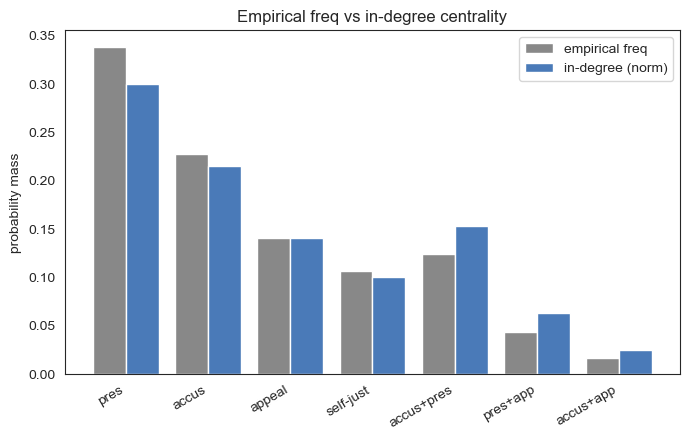

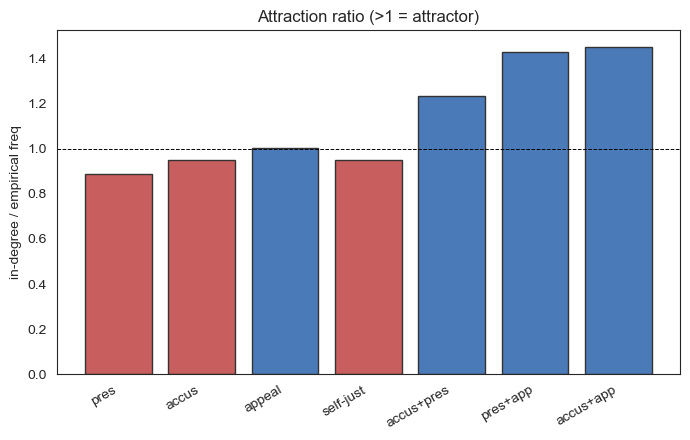

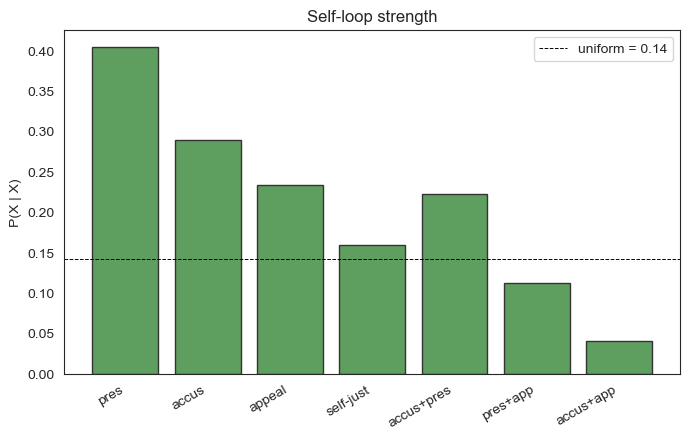

In [10]:
x = np.arange(K)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(x - 0.2, empirical, 0.4, label='empirical freq', color='#888')
ax.bar(x + 0.2, in_deg_norm, 0.4, label='in-degree (norm)', color='#4a7ab8')
ax.set_xticks(x); ax.set_xticklabels([SHORT[s] for s in STATES], rotation=30, ha='right')
ax.set_ylabel('probability mass')
ax.set_title('Empirical freq vs in-degree centrality')
ax.legend()
plt.tight_layout()
plt.savefig('results/fig_03a_node_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

attraction = node_df['attraction_ratio'].values
colors = ['#4a7ab8' if a > 1 else '#c95e5e' for a in attraction]
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(x, attraction, color=colors, edgecolor='#333')
ax.axhline(1, color='black', linewidth=0.7, linestyle='--')
ax.set_xticks(x); ax.set_xticklabels([SHORT[s] for s in STATES], rotation=30, ha='right')
ax.set_ylabel('in-degree / empirical freq')
ax.set_title('Attraction ratio (>1 = attractor)')
plt.tight_layout()
plt.savefig('results/fig_03b_node_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(x, self_loop, color='#5e9e5e', edgecolor='#333')
ax.axhline(BASELINE, color='black', linewidth=0.7, linestyle='--', label=f'uniform = {BASELINE:.2f}')
ax.set_xticks(x); ax.set_xticklabels([SHORT[s] for s in STATES], rotation=30, ha='right')
ax.set_ylabel('P(X | X)')
ax.set_title('Self-loop strength')
ax.legend()
plt.tight_layout()
plt.savefig('results/fig_03c_node_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

In [11]:
def edge_asymmetry(P, min_weight=0.05):
    rows = []
    for i in range(K):
        for j in range(i + 1, K):
            a, b = P[i, j], P[j, i]
            if max(a, b) >= min_weight:
                asym = abs(a - b) / (a + b + 1e-9)
                rows.append({
                    'X': STATES[i], 'Y': STATES[j],
                    'P(X->Y)': a, 'P(Y->X)': b,
                    'asymmetry': asym,
                    'dominant': f'{STATES[i] if a > b else STATES[j]} → {STATES[j] if a > b else STATES[i]}',
                })
    return pd.DataFrame(rows).sort_values('asymmetry', ascending=False)

asym_df = edge_asymmetry(P_global)
asym_df.to_csv('results/edge_asymmetry.csv', sep=';', index=False)
asym_df.head(10)

,X,Y,P(X->Y),P(Y->X),asymmetry,dominant
5,presentation,accusation+appeal,0.016,0.258,0.881,accusation+appeal → presentation
10,accusation,accusation+appeal,0.019,0.186,0.818,accusation+appeal → accusation
14,appeal,accusation+appeal,0.023,0.186,0.783,accusation+appeal → appeal
18,accusation+presentation,accusation+appeal,0.026,0.163,0.721,accusation+appeal → accusation+presentation
4,presentation,presentation+appeal,0.053,0.302,0.701,presentation+appeal → presentation
9,accusation,presentation+appeal,0.031,0.134,0.629,presentation+appeal → accusation
16,self-justification,accusation+appeal,0.021,0.081,0.585,accusation+appeal → self-justification
2,presentation,self-justification,0.073,0.258,0.558,self-justification → presentation
17,accusation+presentation,presentation+appeal,0.058,0.168,0.486,presentation+appeal → accusation+presentation
19,presentation+appeal,accusation+appeal,0.030,0.086,0.482,accusation+appeal → presentation+appeal


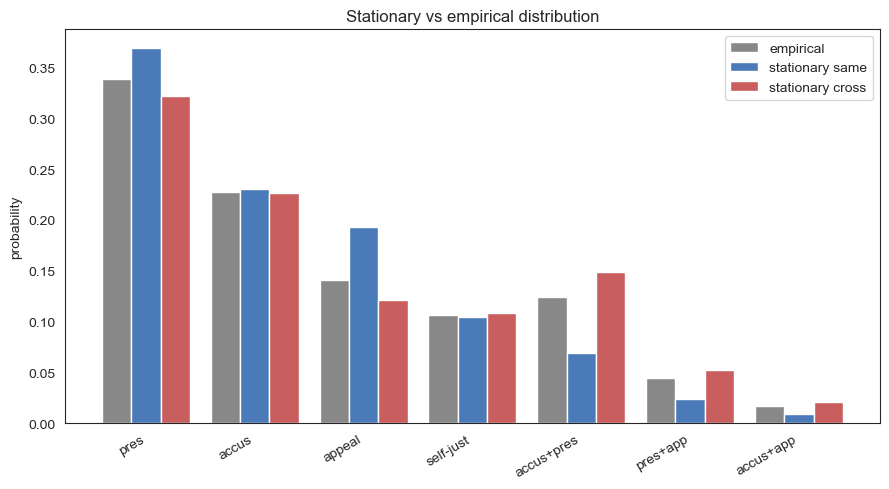

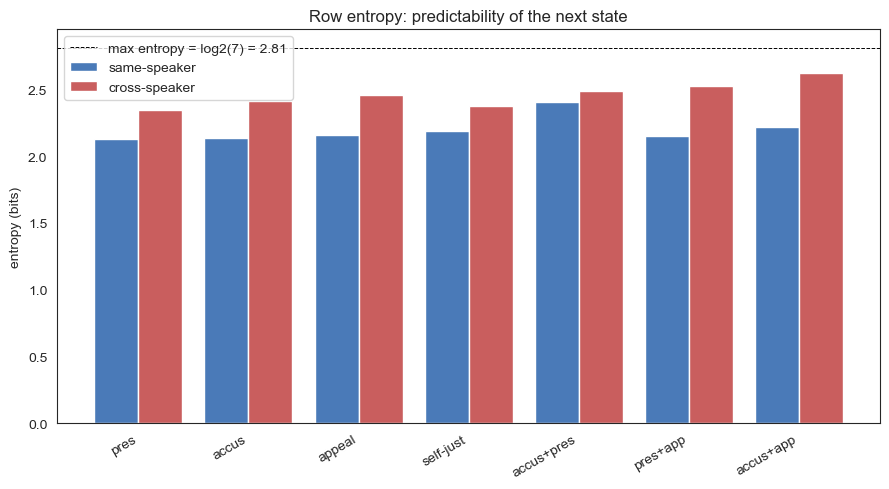

In [12]:
pi_same  = stationary(P_same)
pi_cross = stationary(P_cross)
ent_same  = row_entropies(P_same)
ent_cross = row_entropies(P_cross)

x = np.arange(K); w = 0.27

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - w, empirical, w, label='empirical', color='#888')
ax.bar(x, pi_same, w, label='stationary same', color='#4a7ab8')
ax.bar(x + w, pi_cross, w, label='stationary cross', color='#c95e5e')
ax.set_xticks(x); ax.set_xticklabels([SHORT[s] for s in STATES], rotation=30, ha='right')
ax.set_ylabel('probability'); ax.set_title('Stationary vs empirical distribution')
ax.legend()
plt.tight_layout()
plt.savefig('results/fig_04a_stationary.png', dpi=150, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - 0.2, ent_same,  0.4, label='same-speaker',  color='#4a7ab8')
ax.bar(x + 0.2, ent_cross, 0.4, label='cross-speaker', color='#c95e5e')
ax.axhline(np.log2(K), color='black', linewidth=0.7, linestyle='--',
           label=f'max entropy = log2({K}) = {np.log2(K):.2f}')
ax.set_xticks(x); ax.set_xticklabels([SHORT[s] for s in STATES], rotation=30, ha='right')
ax.set_ylabel('entropy (bits)'); ax.set_title('Row entropy: predictability of the next state')
ax.legend()
plt.tight_layout()
plt.savefig('results/fig_04b_entropy.png', dpi=150, bbox_inches='tight')
plt.show()

## Markov order test (Hypothesis 3)

In [13]:
content_all = df[~df['state'].isin(DROP)].sort_values(['link', 'order'])
triples = []
pairs_for_p1 = []

for _, grp in content_all.groupby('link'):
    states = grp['state'].tolist()
    speakers = grp['speaker'].tolist()
    for i in range(len(states) - 2):
        w, x, y = states[i], states[i + 1], states[i + 2]
        if all(s in STATE_IDX for s in [w, x, y]):
            if speakers[i] != speakers[i + 1] and speakers[i + 1] != speakers[i + 2]:
                triples.append((w, x, y))
                pairs_for_p1.append((x, y))

print(f'Cross-speaker triples: {len(triples)}')

C2 = np.zeros((K, K, K), dtype=int)
for w, x, y in triples:
    C2[STATE_IDX[w], STATE_IDX[x], STATE_IDX[y]] += 1

C1 = np.zeros((K, K), dtype=int)
for x, y in pairs_for_p1:
    C1[STATE_IDX[x], STATE_IDX[y]] += 1

P1 = np.zeros((K, K))
for i in range(K):
    s = C1[i].sum()
    if s > 0: P1[i] = C1[i] / s

P2 = np.zeros((K, K, K))
for w in range(K):
    for x in range(K):
        s = C2[w, x].sum()
        if s > 0: P2[w, x] = C2[w, x] / s

eps = 1e-12
G2 = 0.0
for w in range(K):
    for x in range(K):
        for y in range(K):
            n = C2[w, x, y]
            if n == 0: continue
            p2, p1 = P2[w, x, y], P1[x, y]
            if p2 > eps and p1 > eps:
                G2 += 2 * n * np.log(p2 / p1)

df_test = K * (K - 1) ** 2
p_value = 1 - chi2.cdf(G2, df_test)
effect = G2 / len(triples)

print(f'G² statistic : {G2:.2f}')
print(f'degrees of freedom: {df_test}')
print(f'p-value : {p_value:.2e}')
print(f'effect size G²/n: {effect:.3f}')

result = {
    'n_triples': len(triples), 'G2': G2, 'df': df_test,
    'p_value': p_value, 'effect_size_G2_per_n': effect,
}
pd.DataFrame([result]).to_csv('results/markov_order_test.csv', sep=';', index=False)

Cross-speaker triples: 7639
G² statistic : 737.15
degrees of freedom: 252
p-value : 0.00e+00
effect size G²/n: 0.096


In [14]:
contributions = []
for w in range(K):
    for x in range(K):
        n_wx = C2[w, x].sum()
        if n_wx < 20: continue
        g2_wx = 0
        for y in range(K):
            n_wxy = C2[w, x, y]
            if n_wxy < 1: continue
            p2, p1 = P2[w, x, y], P1[x, y]
            if p2 > eps and p1 > eps:
                g2_wx += 2 * n_wxy * np.log(p2 / p1)
        contributions.append({'W': STATES[w], 'X': STATES[x], 'n': n_wx,
                              'G2_contribution': g2_wx})

contrib_df = pd.DataFrame(contributions).sort_values('G2_contribution', ascending=False)
contrib_df.to_csv('results/markov_order_contributions.csv', sep=';', index=False)
contrib_df.head(10)

,W,X,n,G2_contribution
7,accusation,presentation,432,62.785
22,self-justification,accusation,214,51.350
14,appeal,presentation,361,41.257
0,presentation,presentation,1059,32.865
26,accusation+presentation,presentation,299,29.411
35,presentation+appeal,appeal,97,27.812
15,appeal,accusation,167,26.423
9,accusation,appeal,128,25.780
18,appeal,accusation+presentation,140,25.490
10,accusation,self-justification,261,23.806


## Hypothesis 2: primary vs general elections

General cross-speaker transitions:  2397
Primary cross-speaker transitions:  8902


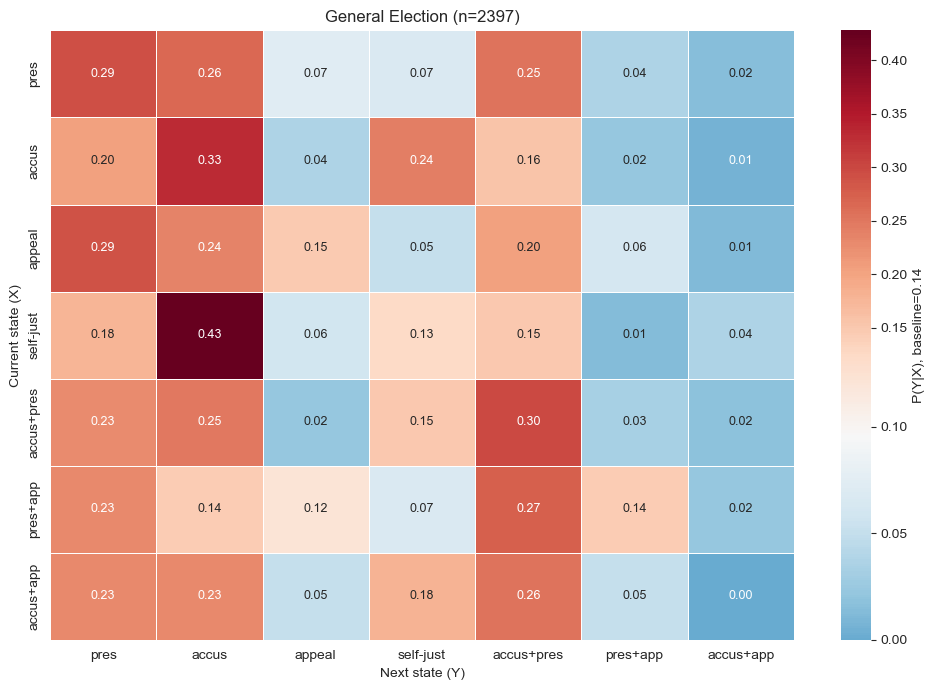

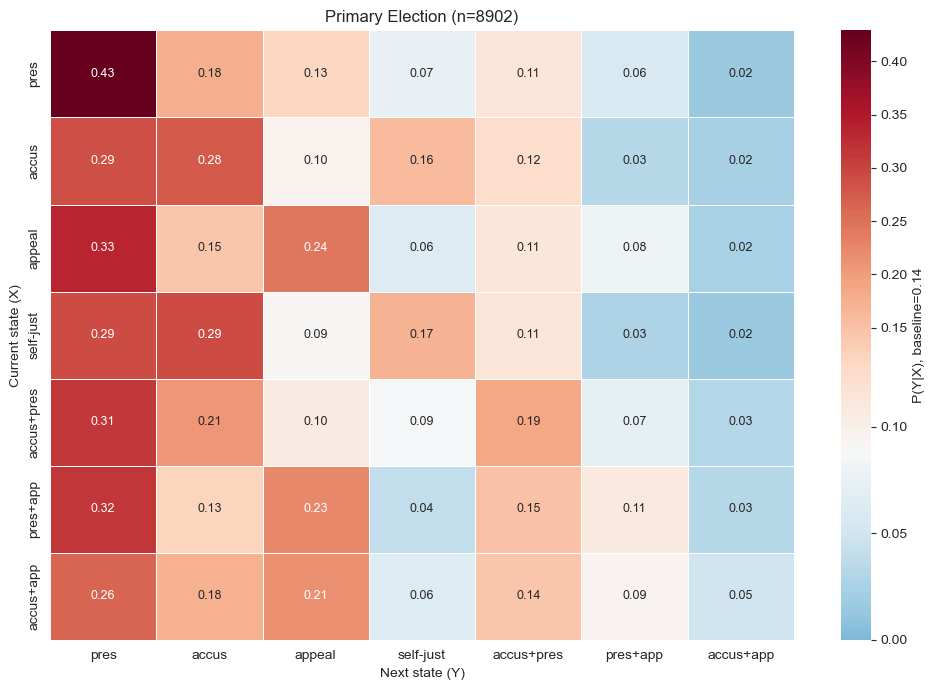

In [40]:
df_general = df[df['election_type'] == 'General Election']
df_primary = df[df['election_type'].isin(
    ['Primary Election: Republican Party', 'Primary Election: Democratic Party'])]

C_gen, P_gen = build_matrix(collect_cross(df_general))
C_pri, P_pri = build_matrix(collect_cross(df_primary))

print(f'General cross-speaker transitions:  {C_gen.sum()}')
print(f'Primary cross-speaker transitions:  {C_pri.sum()}')

# General
fig, ax = plt.subplots(figsize=(10, 7))
plot_diverging_matrix(P_gen, f'General Election (n={C_gen.sum()})', ax)
plt.tight_layout()
plt.savefig('results/fig_05a_general.png', dpi=300, bbox_inches='tight')
plt.show()

# Primary
fig, ax = plt.subplots(figsize=(10, 7))
plot_diverging_matrix(P_pri, f'Primary Election (n={C_pri.sum()})', ax)
plt.tight_layout()
plt.savefig('results/fig_05b_primary.png', dpi=300, bbox_inches='tight')
plt.show()

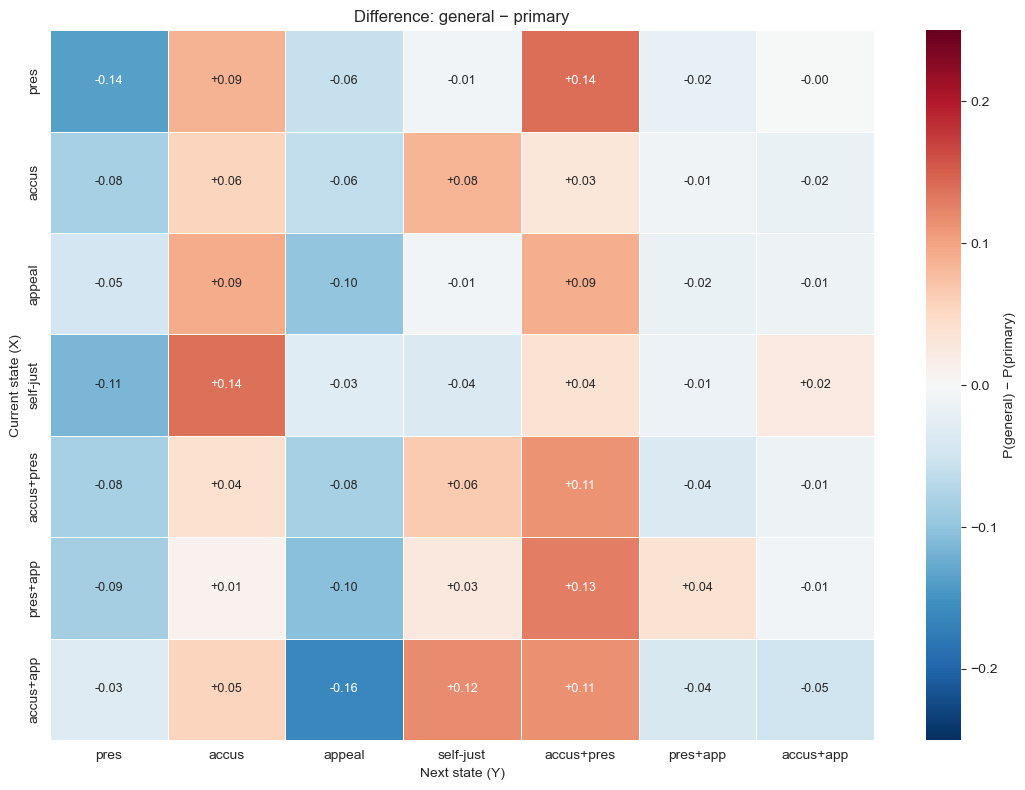

Chi-square test (H0: same transition distribution)
  chi2 = 764.70, df = 48, p = 9.07e-130
  Cramer V (effect size): 0.260


In [16]:
fig, ax = plt.subplots(figsize=(11, 8))
plot_diff_matrix(P_gen, P_pri, 'general', 'primary', ax, vmax=0.25)
plt.tight_layout()
plt.savefig('results/fig_06_diff_general_primary.png', dpi=150, bbox_inches='tight')
plt.show()

from scipy.stats import chi2_contingency
combined = np.stack([C_gen, C_pri])  # shape (2, K, K)
flat = combined.reshape(2, -1)
chi2_stat, p_val, dof, expected = chi2_contingency(flat)
print(f'Chi-square test (H0: same transition distribution)')
print(f'  chi2 = {chi2_stat:.2f}, df = {dof}, p = {p_val:.2e}')
n = combined.sum()
cramers_v = np.sqrt(chi2_stat / (n * (min(flat.shape) - 1)))
print(f'  Cramer V (effect size): {cramers_v:.3f}')

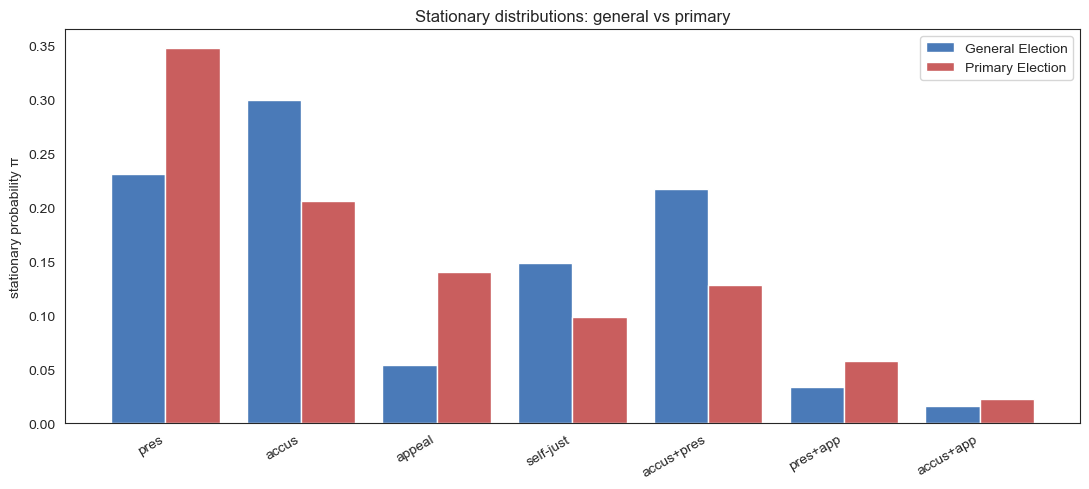

In [39]:
pi_gen, pi_pri = stationary(P_gen), stationary(P_pri)
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(K); w = 0.4
ax.bar(x - w/2, pi_gen, w, label='General Election',  color='#4a7ab8')
ax.bar(x + w/2, pi_pri, w, label='Primary Election',  color='#c95e5e')
ax.set_xticks(x); ax.set_xticklabels([SHORT[s] for s in STATES], rotation=30, ha='right')
ax.set_ylabel('stationary probability π')
ax.set_title('Stationary distributions: general vs primary')
ax.legend()
plt.tight_layout()
plt.savefig('results/fig_07_stationary_general_primary.png', dpi=300, bbox_inches='tight')
plt.show()

In [42]:
fig_gen_graph = plot_graph_topk_plotly(P_gen, top_k=3, min_weight=0.10)
fig_gen_graph.update_layout(title=dict(x=0.5, font=dict(size=16)))
fig_gen_graph.show()

fig_pri_graph = plot_graph_topk_plotly(P_pri, top_k=3, min_weight=0.10)
fig_pri_graph.update_layout(title=dict(x=0.5, font=dict(size=16)))
fig_pri_graph.show()

## Hypothesis 1: party differences

Republican cross-speaker:  5212
Democratic cross-speaker:  3690


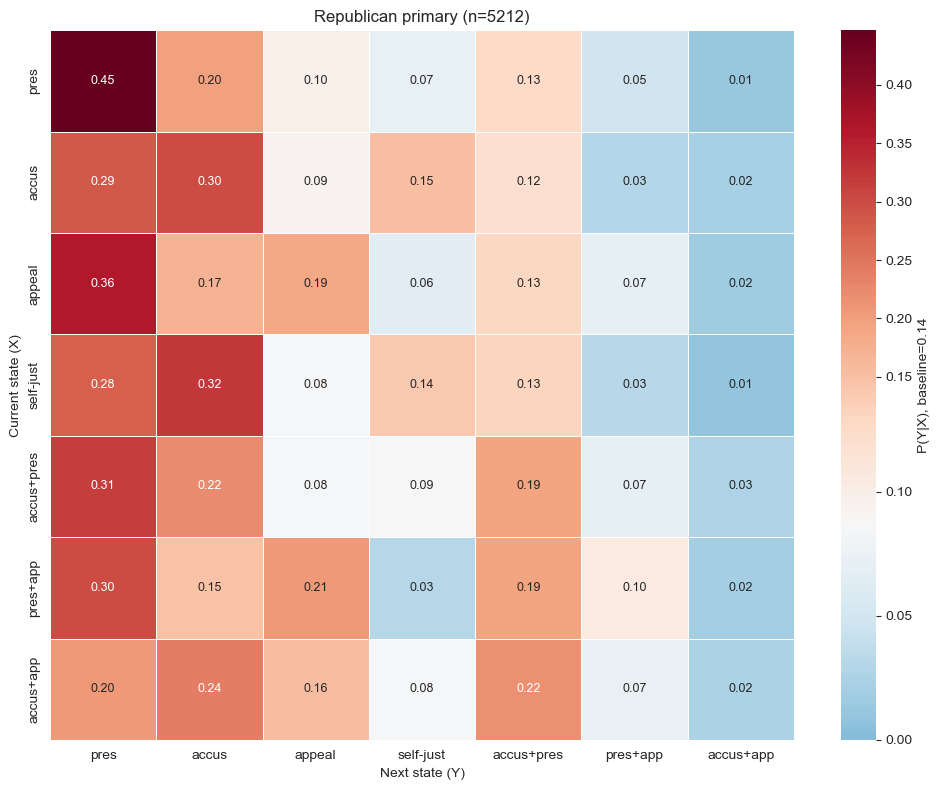

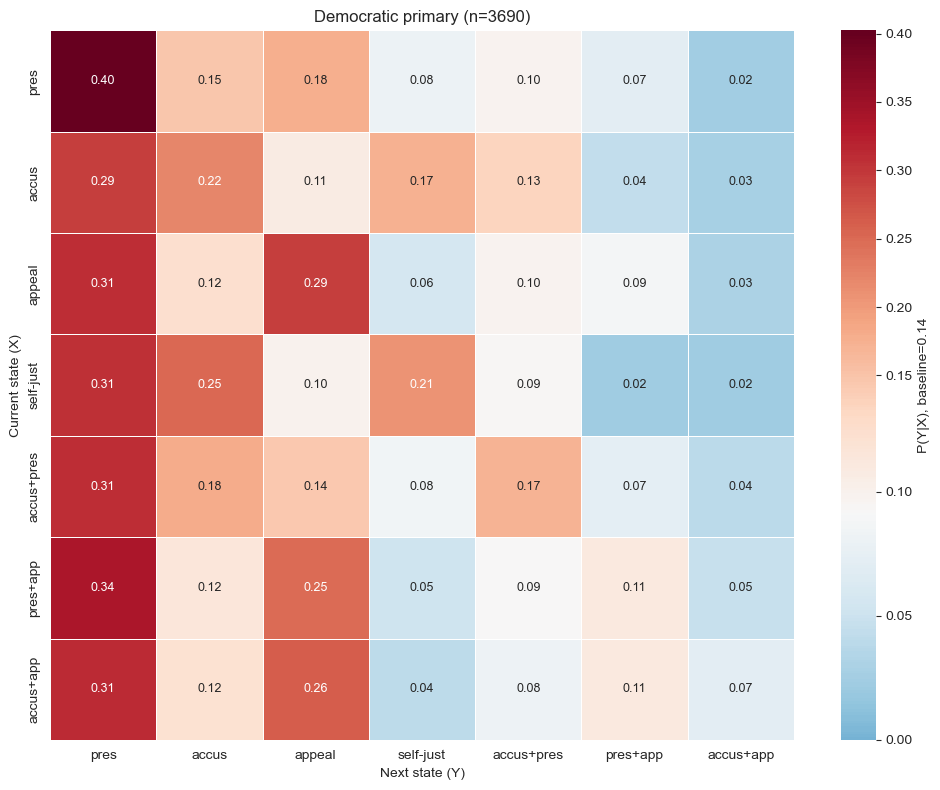

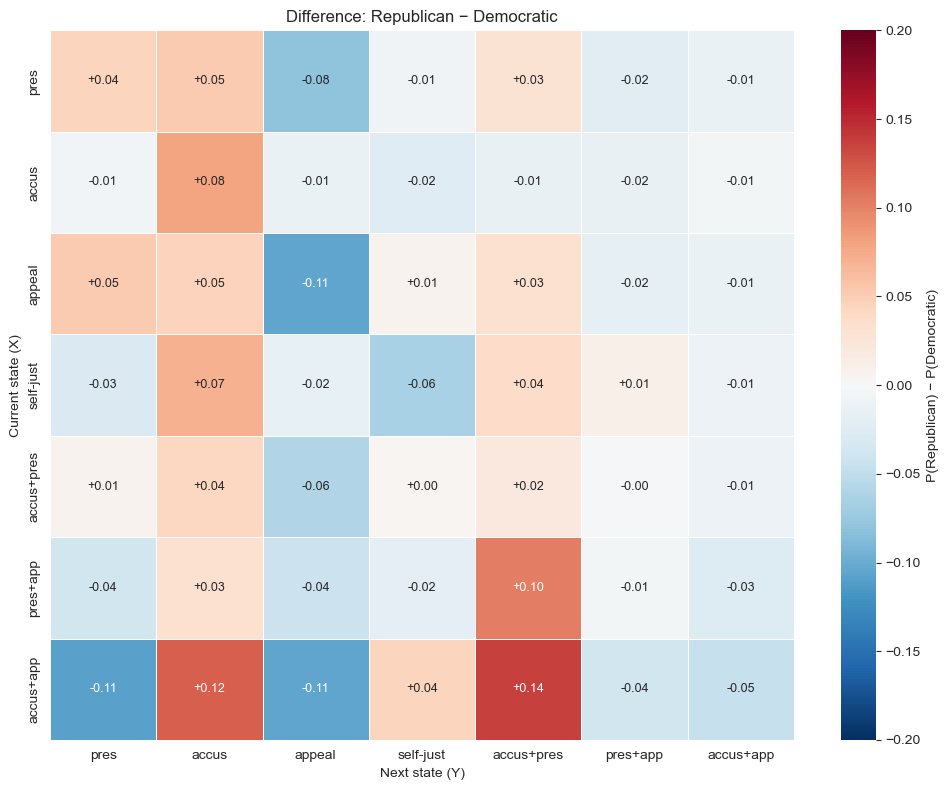

In [19]:
df_rep = df[df['election_type'] == 'Primary Election: Republican Party']
df_dem = df[df['election_type'] == 'Primary Election: Democratic Party']

C_rep, P_rep = build_matrix(collect_cross(df_rep))
C_dem, P_dem = build_matrix(collect_cross(df_dem))

print(f'Republican cross-speaker:  {C_rep.sum()}')
print(f'Democratic cross-speaker:  {C_dem.sum()}')

# Republican
fig, ax = plt.subplots(figsize=(10, 8))
plot_diverging_matrix(P_rep, f'Republican primary (n={C_rep.sum()})', ax)
plt.tight_layout()
plt.savefig('results/fig_08a_republican.png', dpi=300, bbox_inches='tight')
plt.show()

# Democratic
fig, ax = plt.subplots(figsize=(10, 8))
plot_diverging_matrix(P_dem, f'Democratic primary (n={C_dem.sum()})', ax)
plt.tight_layout()
plt.savefig('results/fig_08b_democratic.png', dpi=300, bbox_inches='tight')
plt.show()

# Difference
fig, ax = plt.subplots(figsize=(10, 8))
plot_diff_matrix(P_rep, P_dem, 'Republican', 'Democratic', ax, vmax=0.20)
plt.tight_layout()
plt.savefig('results/fig_08c_diff.png', dpi=300, bbox_inches='tight')
plt.show()

In [20]:
combined = np.stack([C_rep, C_dem])
flat = combined.reshape(2, -1)
chi2_stat, p_val, dof, expected = chi2_contingency(flat)
n = combined.sum()
cramers_v = np.sqrt(chi2_stat / (n * (min(flat.shape) - 1)))
print(f'Chi-square test (H0: same distribution for Rep vs Dem primaries)')
print(f'  chi2 = {chi2_stat:.2f}, df = {dof}, p = {p_val:.2e}')
print(f'  Cramer V: {cramers_v:.3f}')

hyp_results = pd.DataFrame([
    {'hypothesis': 'H2: general vs primary',
     'chi2': None, 'p_value': None, 'cramers_v': None},
])

Chi-square test (H0: same distribution for Rep vs Dem primaries)
  chi2 = 408.37, df = 48, p = 1.24e-58
  Cramer V: 0.214


In [21]:
from scipy.stats import chi2_contingency

def chi2_test_matrices(C_a, C_b):
    combined = np.stack([C_a, C_b])
    flat = combined.reshape(2, -1)
    chi2_stat, p_val, dof, _ = chi2_contingency(flat)
    n = combined.sum()
    v = np.sqrt(chi2_stat / (n * (min(flat.shape) - 1)))
    return chi2_stat, p_val, dof, v

chi2_gp, p_gp, dof_gp, v_gp = chi2_test_matrices(C_gen, C_pri)
chi2_rd, p_rd, dof_rd, v_rd = chi2_test_matrices(C_rep, C_dem)

hyp_results = pd.DataFrame([
    {'hypothesis': 'H1: Republican vs Democratic primaries',
     'chi2': chi2_rd, 'df': dof_rd, 'p_value': p_rd, 'cramers_v': v_rd,
     'verdict': 'rejected (matrices differ)' if p_rd < 0.05 else 'not rejected'},
    {'hypothesis': 'H2: General vs Primary elections',
     'chi2': chi2_gp, 'df': dof_gp, 'p_value': p_gp, 'cramers_v': v_gp,
     'verdict': 'rejected (matrices differ)' if p_gp < 0.05 else 'not rejected'},
    {'hypothesis': 'H3: First-order Markov (G²-test)',
     'chi2': G2, 'df': df_test, 'p_value': p_value, 'cramers_v': effect,
     'verdict': f'formally rejected (p={p_value:.0e}), but effect size G²/n={effect:.2f}'},
])
hyp_results.to_csv('results/hypothesis_tests.csv', sep=';', index=False)
hyp_results

,hypothesis,chi2,df,p_value,cramers_v,verdict
0,H1: Republican vs Democratic primaries,408.367,48,0.000,0.214,rejected (matrices differ)
1,H2: General vs Primary elections,764.703,48,0.000,0.260,rejected (matrices differ)
2,H3: First-order Markov (G²-test),737.146,252,0.000,0.096,"formally rejected (p=0e+00), but effect size G..."


In [33]:
fig_rep_graph = plot_graph_topk_plotly(P_rep, top_k=3, min_weight=0.10)
fig_rep_graph.update_layout(title=dict(x=0.5, font=dict(size=16)))
fig_rep_graph.show()

fig_dem_graph = plot_graph_topk_plotly(P_dem, top_k=3, min_weight=0.10)
fig_dem_graph.update_layout(title=dict(x=0.5, font=dict(size=16)))
fig_dem_graph.show()

## Historical evolution (H3)

1960-2000 cross-speaker: 1151
2000-2024 cross-speaker: 10148


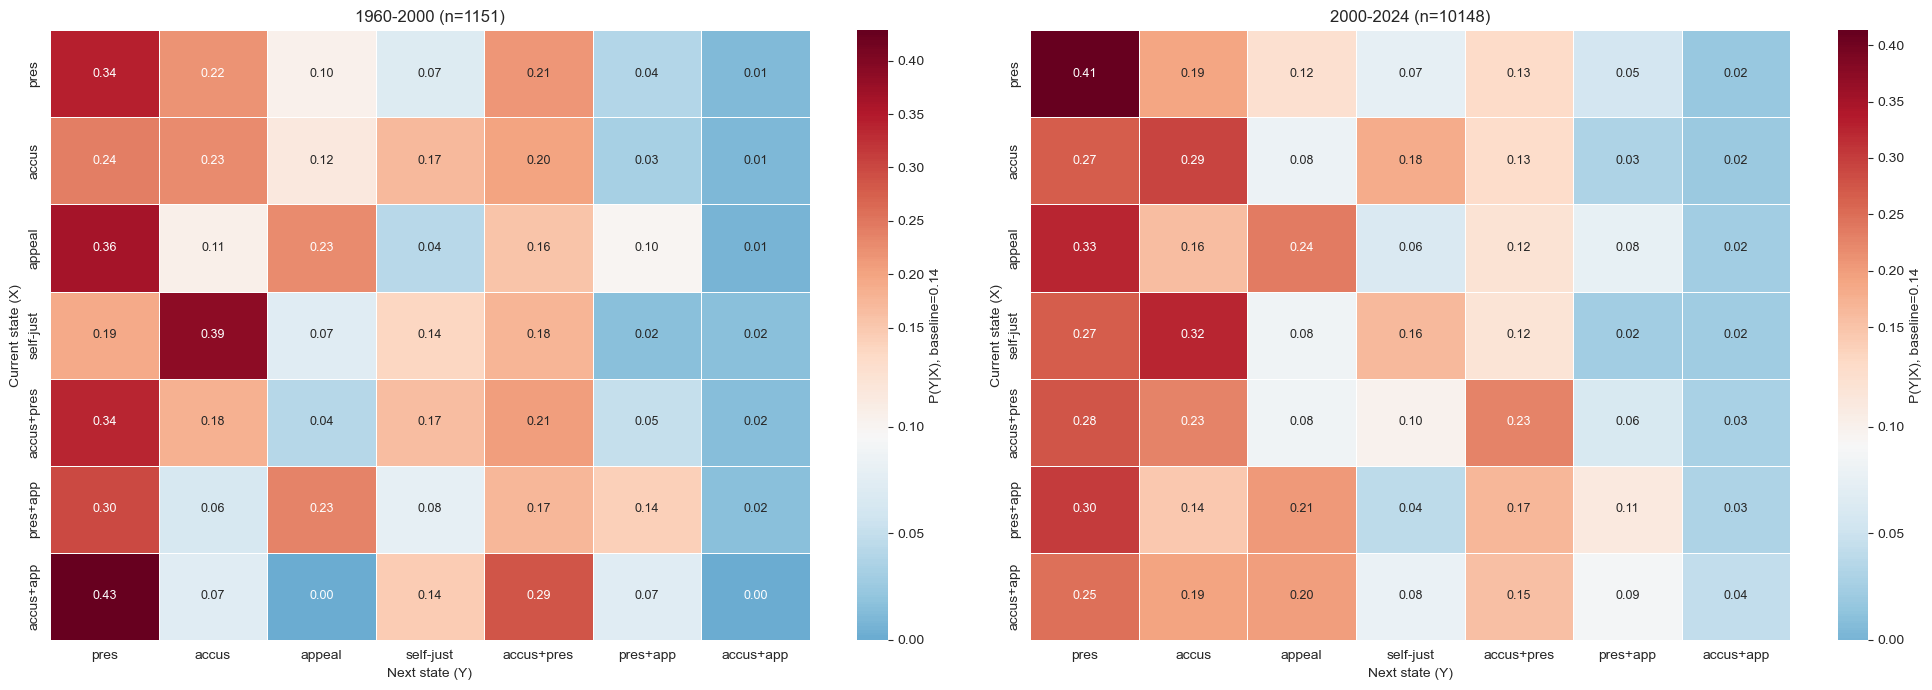

In [23]:
def period(y):
    if pd.isna(y): return None
    return '1960-2000' if y < 2000 else '2000-2024'
df['period'] = df['year'].apply(period)

C_early, P_early = build_matrix(collect_cross(df[df['period'] == '1960-2000']))
C_late,  P_late  = build_matrix(collect_cross(df[df['period'] == '2000-2024']))

print(f'1960-2000 cross-speaker: {C_early.sum()}')
print(f'2000-2024 cross-speaker: {C_late.sum()}')

fig, axes = plt.subplots(1, 2, figsize=(20, 7))
plot_diverging_matrix(P_early, f'1960-2000 (n={C_early.sum()})', axes[0])
plot_diverging_matrix(P_late,  f'2000-2024 (n={C_late.sum()})',  axes[1])
plt.tight_layout()
plt.savefig('results/fig_09_periods.png', dpi=150, bbox_inches='tight')
plt.show()

1960-2004 general cross-speaker: 1145
2008-2024 general cross-speaker: 1252


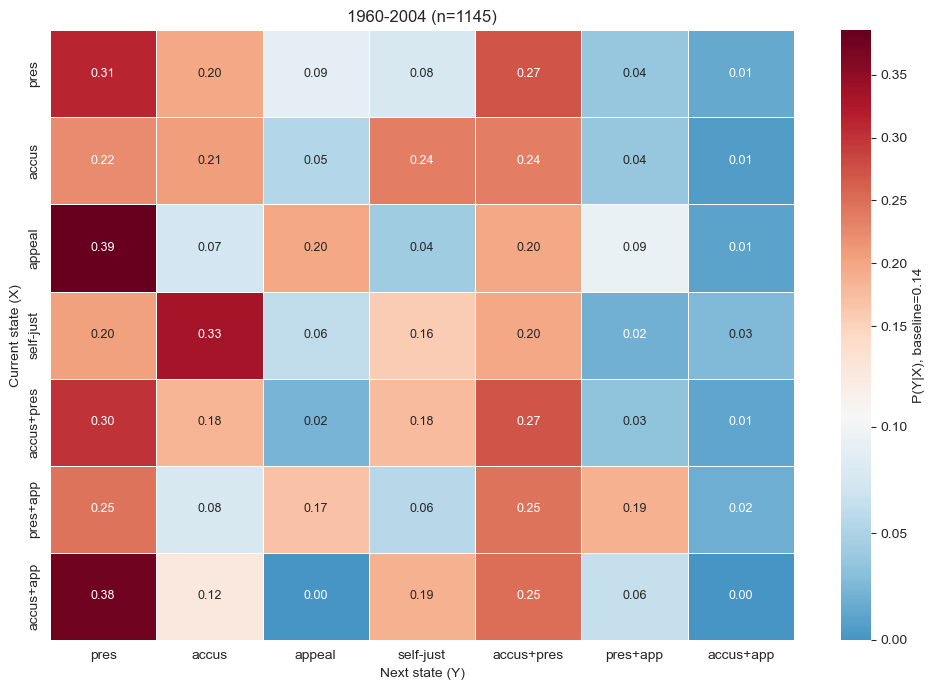

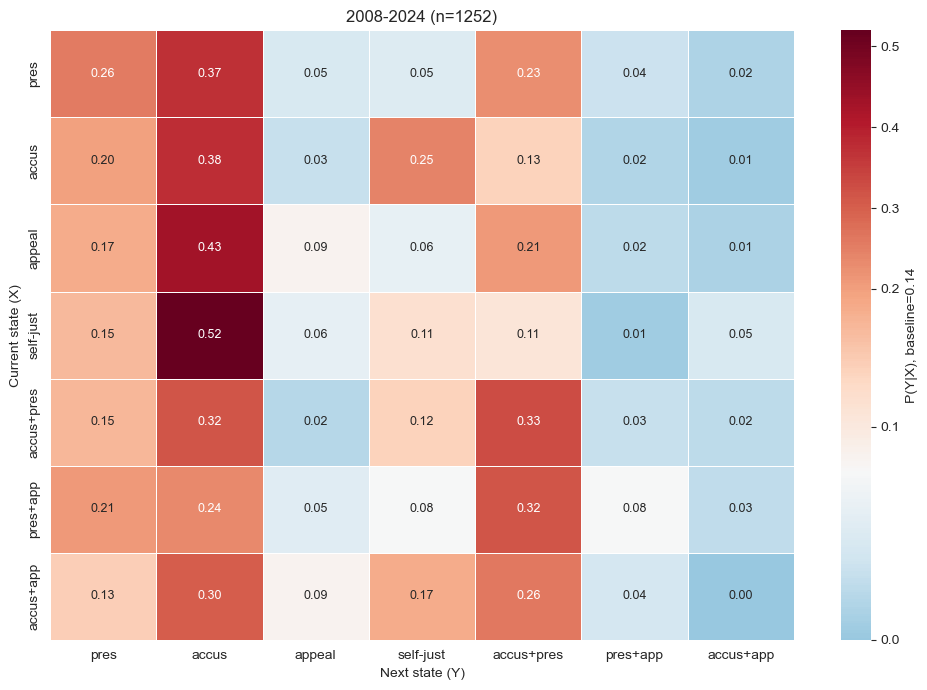

In [45]:
def period(y):
    if pd.isna(y): return None
    return '1960-2004' if y <= 2004 else '2008-2024'
df['period'] = df['year'].apply(period)

df_general_only = df[df['election_type'] == 'General Election']

C_early, P_early = build_matrix(collect_cross(
    df_general_only[df_general_only['period'] == '1960-2004']))
C_late,  P_late  = build_matrix(collect_cross(
    df_general_only[df_general_only['period'] == '2008-2024']))

print(f'1960-2004 general cross-speaker: {C_early.sum()}')
print(f'2008-2024 general cross-speaker: {C_late.sum()}')

# 1960-2004
fig, ax = plt.subplots(figsize=(10, 7))
plot_diverging_matrix(P_early, f'1960-2004 (n={C_early.sum()})', ax)
plt.tight_layout()
plt.savefig('results/fig_09a_early.png', dpi=300, bbox_inches='tight')
plt.show()

# 2008-2024
fig, ax = plt.subplots(figsize=(10, 7))
plot_diverging_matrix(P_late, f'2008-2024 (n={C_late.sum()})', ax)
plt.tight_layout()
plt.savefig('results/fig_09b_late.png', dpi=300, bbox_inches='tight')
plt.show()

In [36]:
combined = np.stack([C_early, C_late])
flat = combined.reshape(2, -1).astype(float)
flat += 0.5

chi2_stat, p_val, dof, expected = chi2_contingency(flat)
n = combined.sum()
cramers_v = np.sqrt(chi2_stat / (n * (min(flat.shape) - 1)))
print(f'Chi-square test (H0: same distribution for 1960-2004 vs 2008-2024 general elections)')
print(f'  chi2 = {chi2_stat:.2f}, df = {dof}, p = {p_val:.2e}')
print(f'  Cramer V: {cramers_v:.3f}')

Chi-square test (H0: same distribution for 1960-2004 vs 2008-2024 general elections)
  chi2 = 299.93, df = 48, p = 3.78e-38
  Cramer V: 0.354


In [46]:
fig_early_graph = plot_graph_topk_plotly(P_early, top_k=3, min_weight=0.10)
fig_early_graph.update_layout(title=dict(x=0.5, font=dict(size=16)))
fig_early_graph.show()

fig_late_graph = plot_graph_topk_plotly(P_late, top_k=3, min_weight=0.10)
fig_late_graph.update_layout(title=dict(x=0.5, font=dict(size=16)))
fig_late_graph.show()